## Fine Tuning in Computer Vision

In [59]:
# Download helper functions

!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-07-07 13:44:26--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-07-07 13:44:27 (125 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [60]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, walk_through_dir

## MODEL 0

In [61]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

--2026-07-07 13:44:27--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.142.207, 74.125.195.207, 172.253.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.142.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  98.6MB/s    in 1.6s    

2026-07-07 13:44:29 (98.6 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [62]:
unzip_data("10_food_classes_10_percent.zip")

In [63]:
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent

In [64]:
train_dir = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

In [65]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)

test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)


Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [66]:
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [67]:
# first we are building feature extraction model to compare
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name='Input Layer')

# efficient net requires the input image in the form (0 - 255), but resnet doesn't see the 02_feature_extraction notebook

x = base_model(inputs)

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

outputs = tf.keras.layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

model_0 = tf.keras.Model(inputs, outputs)

model_0.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

model_0.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [68]:
history_0 = model_0.fit(
    train_data_10_percent,
    epochs=5,
    validation_data=test_data_10_percent,
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4547 - loss: 1.8677 - val_accuracy: 0.7188 - val_loss: 1.3145
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.7360 - loss: 1.1395 - val_accuracy: 0.8068 - val_loss: 0.8893
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.8213 - loss: 0.8295 - val_accuracy: 0.8384 - val_loss: 0.7100
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.8520 - loss: 0.6769 - val_accuracy: 0.8504 - val_loss: 0.6196
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.8680 - loss: 0.5823 - val_accuracy: 0.8600 - val_loss: 0.5602


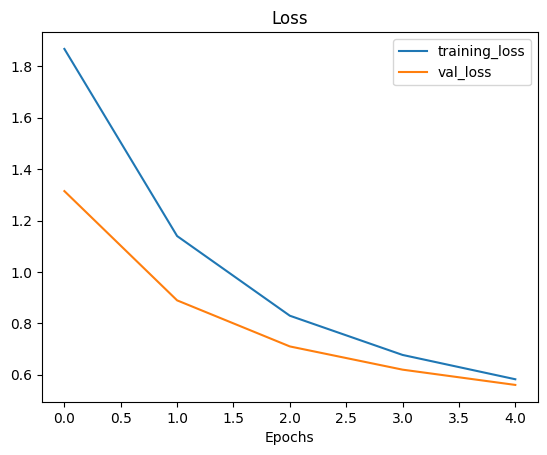

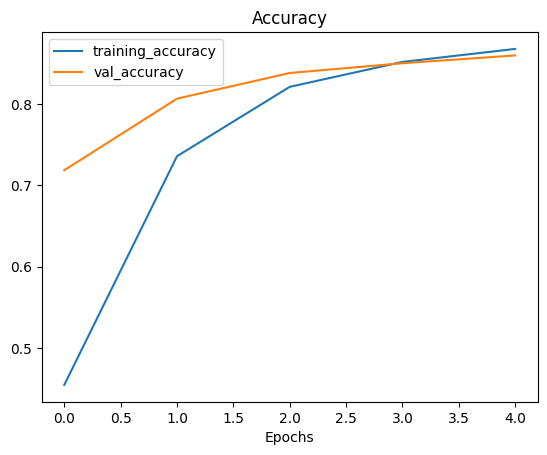

In [69]:
plot_loss_curves(history_0)

## Further Experiments

1. `model_1` use feature extraction transfer learning with 1% of training data with data augmentation
2. `model_2` use feature extraction transfer learning with 10% of training data with augmentation
3. `model_3` use fine-tuning transfer learning on 10% of the training data.
4. `model_4`use fine-tuning transfer learning on 100% of the training data with data augmentation

**NOTE** throughout all the experiments the same test dataset will be used to evaluate our model; this ensures consistency across evaluation metrics.

## MODEL 1

In [70]:
# download and unzip 1% of the data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip

--2026-07-07 13:45:59--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.99.207, 142.250.107.207, 173.194.43.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.99.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M   208MB/s    in 0.6s    

2026-07-07 13:45:59 (208 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [71]:
unzip_data("10_food_classes_1_percent.zip")

In [72]:
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir_1_percent = "10_food_classes_1_percent/test"

In [73]:
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/fried_rice'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/hamburger'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_wings'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/grilled_salmon'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_curry'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/pizza'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ice_cream'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/steak'.
There a

In [74]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir_1_percent,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)

test_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir_1_percent,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)


Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [75]:
# first we are building feature extraction model to compare
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name='Input Layer')

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
], name='data_augmentation')

x = data_augmentation(inputs)

# efficient net requires the input image in the form (0 - 255), but resnet doesn't see the 02_feature_extraction notebook
x = base_model(x)

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

outputs = tf.keras.layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

model_1 = tf.keras.Model(inputs, outputs)

model_1.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    train_data_1_percent,
    epochs=5,
    validation_data=test_data_1_percent,
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.0571 - loss: 2.4176 - val_accuracy: 0.1284 - val_loss: 2.2499
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.1714 - loss: 2.2050 - val_accuracy: 0.2460 - val_loss: 2.1219
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2571 - loss: 2.0123 - val_accuracy: 0.3440 - val_loss: 2.0151
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3857 - loss: 1.9232 - val_accuracy: 0.4232 - val_loss: 1.9246
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.4429 - loss: 1.7810 - val_accuracy: 0.4764 - val_loss: 1.8423


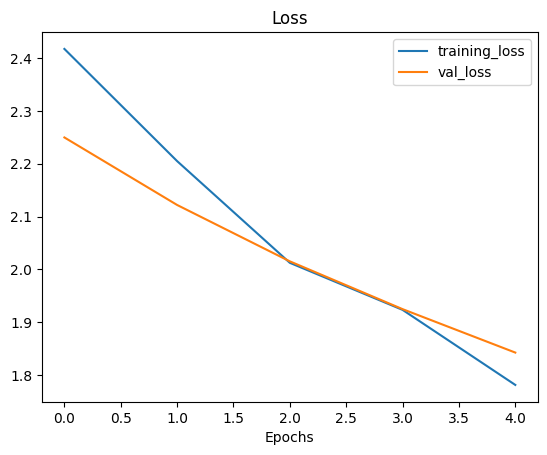

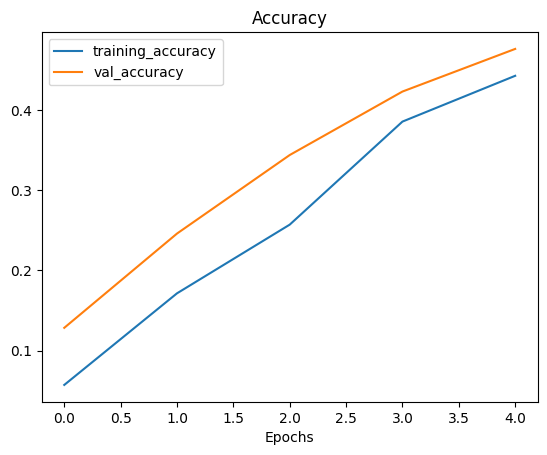

In [76]:
plot_loss_curves(history_1)

## MODEL 2

In [77]:
# first we are building feature extraction model to compare
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name='Input Layer')

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
], name='data_augmentation')

x = data_augmentation(inputs)

# efficient net requires the input image in the form (0 - 255), but resnet doesn't see the 02_feature_extraction notebook
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

outputs = tf.keras.layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

model_2 = tf.keras.Model(inputs, outputs)

model_2.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

checkpoint_path = "10_percent_checkpoints/checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    save_best_only=True,
    save_freq="epoch",
    verbose=1,
)

history_2 = model_2.fit(
    train_data_10_percent,
    epochs=5,
    validation_data=test_data_10_percent,
    callbacks=[checkpoint_callback]
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.1948 - loss: 2.2465
Epoch 1: val_loss improved from None to 1.56899, saving model to 10_percent_checkpoints/checkpoint.weights.h5

Epoch 1: finished saving model to 10_percent_checkpoints/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 535ms/step - accuracy: 0.2973 - loss: 2.0821 - val_accuracy: 0.5808 - val_loss: 1.5690
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5890 - loss: 1.5638
Epoch 2: val_loss improved from 1.56899 to 1.12843, saving model to 10_percent_checkpoints/checkpoint.weights.h5

Epoch 2: finished saving model to 10_percent_checkpoints/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 445ms/step - accuracy: 0.6147 - loss: 1.4832 - val_accuracy: 0.7292 - val_loss: 1.1284
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6844 - loss: 1.2243
Epoch 3: val_loss improved from 1.12843 to 0.90469, saving model to 10_percent_checkpoints/checkpoint.weights.h5

Epoch 3: fin

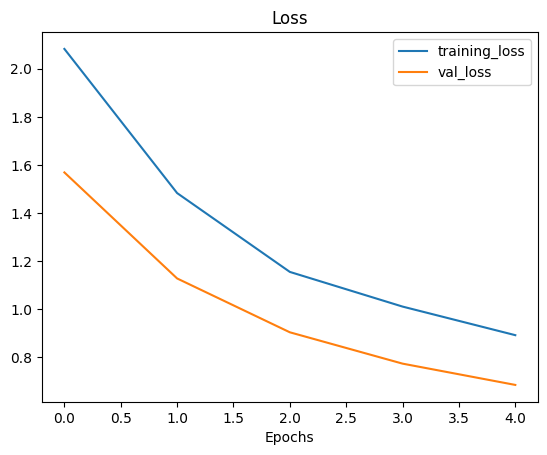

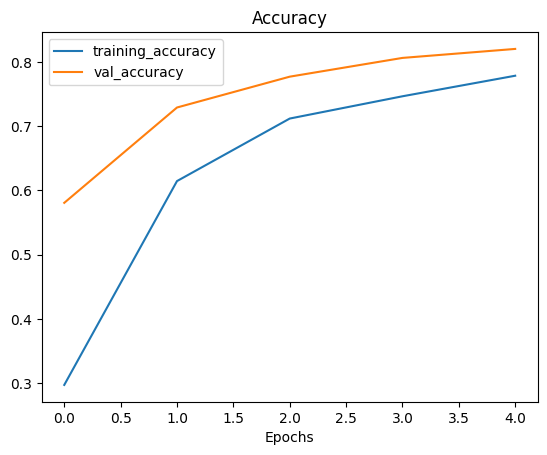

In [78]:
plot_loss_curves(history_2)

In [79]:
# loading the best model from checkpoint and checking its accuracy on test model
model_2.load_weights(checkpoint_path)
model_2.evaluate(test_data_10_percent)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8204 - loss: 0.6860


[0.6860471367835999, 0.8203999996185303]

## Checking which layers are trainable in model2's efficient net layer

## MODEL 3 (Fine Tuning)

In [99]:
# model_3 = fine-tuned version of model_2 (same architecture & trained weights, continuing training)

# Load the best weights saved from model_2's feature extraction training
model_2.load_weights(checkpoint_path)

# Point model_3 at the same underlying model as model_2
model_3 = model_2

base_model = model_3.layers[2]  # replace 2 with the correct index from above
base_model.trainable = True

# Only make the last 10 layers of the base model trainable
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Must recompile after changing `trainable`, with a lower learning rate for fine-tuning
model_3.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["accuracy"]
)

initial_epochs = 5
fine_tune_epochs = initial_epochs + 5

history_3 = model_3.fit(
    train_data_10_percent,
    epochs=fine_tune_epochs,
    initial_epoch=history_2.epoch[-1],  # correct now — model_3 IS model_2, continuing its training
    validation_data=test_data_10_percent,
)

Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.7587 - loss: 1.0064 - val_accuracy: 0.8208 - val_loss: 0.7373
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step - accuracy: 0.7893 - loss: 0.9120 - val_accuracy: 0.8292 - val_loss: 0.6646
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 330ms/step - accuracy: 0.8053 - loss: 0.8580 - val_accuracy: 0.8360 - val_loss: 0.6094
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 362ms/step - accuracy: 0.8013 - loss: 0.7741 - val_accuracy: 0.8404 - val_loss: 0.5663
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.8093 - loss: 0.7434 - val_accuracy: 0.8428 - val_loss: 0.5456
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 329ms/step - accuracy: 0.8333 - loss: 0.6810 - val_accuracy: 0.8488 - val_loss: 0.5201


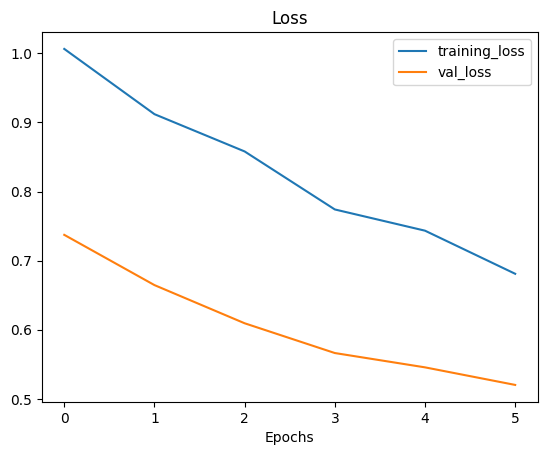

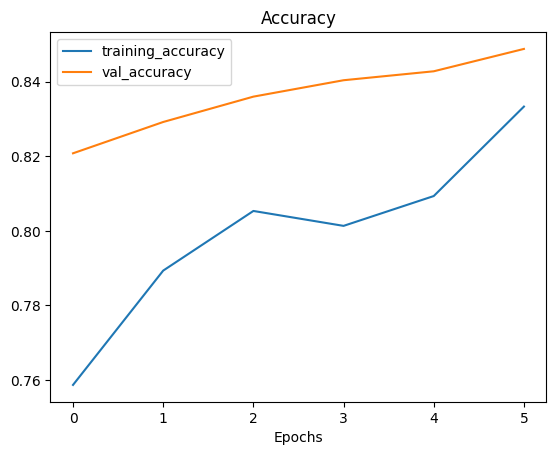

In [100]:
plot_loss_curves(history_3)

In [101]:
import matplotlib.pyplot as plt

def compare_history(history_1, history_2, initial_epochs=5):
  """
  Compare 2 TensorFlow History objects.
  """
  acc = history_1.history["accuracy"]
  loss = history_1.history["loss"]

  val_acc = history_1.history["val_accuracy"]
  val_loss = history_1.history["val_loss"]

  # Combine original history metrics with new history metrics
  total_acc = acc + history_2.history["accuracy"]
  total_loss = loss + history_2.history["loss"]

  total_val_acc = val_acc + history_2.history["val_accuracy"]
  total_val_loss = val_loss + history_2.history["val_loss"]

  plt.figure(figsize=(8, 8))

  # Accuracy subplot
  plt.subplot(2, 1, 1)
  plt.plot(total_acc, label='Training Accuracy')
  plt.plot(total_val_acc, label='Validation Accuracy')
  plt.plot([initial_epochs-1, initial_epochs-1],
          plt.ylim(), color='r', label='Start Fine Tuning') # reshift plot around epochs
  plt.legend(loc='lower right')
  plt.title('Training and Validation Accuracy')

  # Loss subplot
  plt.subplot(2, 1, 2)
  plt.plot(total_loss, label='Training Loss')
  plt.plot(total_val_loss, label='Validation Loss')
  plt.plot([initial_epochs-1, initial_epochs-1],
          plt.ylim(), color='r', label='Start Fine Tuning') # reshift plot around epochs
  plt.legend(loc='upper right')
  plt.title('Training and Validation Loss')
  plt.xlabel('epoch')
  plt.show()

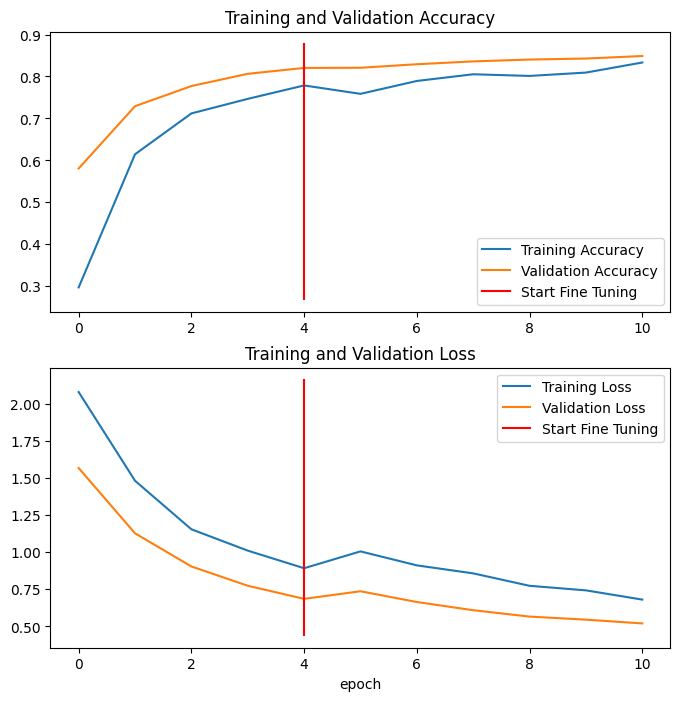

In [102]:
compare_history(history_2, history_3)

## MODEL 4 (Fine-Tuning with 100% data)

In [103]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-07-07 14:07:11--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.188.207, 192.178.163.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.188.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip.1’

10_food_classes_all 100%[===================>] 495.13M  47.9MB/s    in 12s     

2026-07-07 14:07:23 (40.8 MB/s) - ‘10_food_classes_all_data.zip.1’ saved [519183241/519183241]



In [104]:
unzip_data("10_food_classes_all_data.zip")

In [105]:
train_dir_100_percent = "10_food_classes_all_data/train"
test_dir_100_percent = "10_food_classes_all_data/test"

In [106]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data_100_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir_100_percent,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)

test_data_100_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir_100_percent,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)


Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [107]:
# we are building feature extracted model, because we need the last epoch value from the history object of previous feature extracted model
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name='Input Layer')

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
], name='data_augmentation')

x = data_augmentation(inputs)

# efficient net requires the input image in the form (0 - 255), but resnet doesn't see the 02_feature_extraction notebook
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

outputs = tf.keras.layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

model_4 = tf.keras.Model(inputs, outputs)

model_4.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_4 = model_4.fit(
    train_data_100_percent,
    epochs=5,
    validation_data=test_data_100_percent,
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.6659 - loss: 1.1219 - val_accuracy: 0.8616 - val_loss: 0.4876
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 132ms/step - accuracy: 0.7780 - loss: 0.7167 - val_accuracy: 0.8828 - val_loss: 0.3892
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.7969 - loss: 0.6466 - val_accuracy: 0.8912 - val_loss: 0.3497
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.8116 - loss: 0.5935 - val_accuracy: 0.8896 - val_loss: 0.3350
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.8148 - loss: 0.5669 - val_accuracy: 0.8968 - val_loss: 0.3188


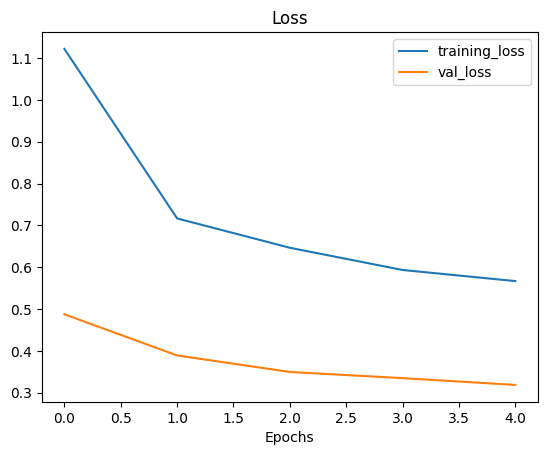

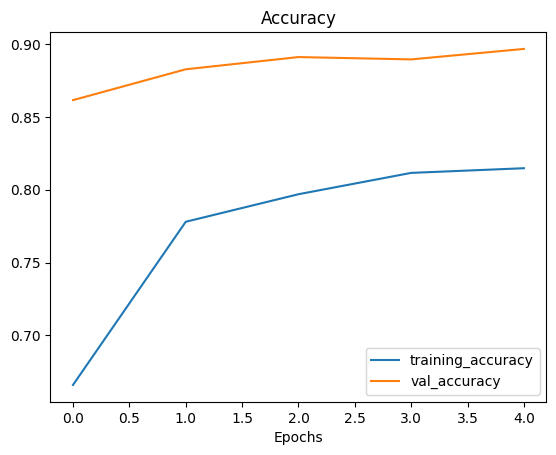

In [109]:
plot_loss_curves(history_4)

In [108]:
# model_5 = fine-tuned version of model_4 (same architecture & trained weights, continuing training)

# Point model_5 at the same underlying model as model_4
model_5 = model_4

base_model = model_5.layers[2]  # replace 2 with the correct index from above
base_model.trainable = True

# Only make the last 10 layers of the base model trainable
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Must recompile after changing `trainable`, with a lower learning rate for fine-tuning
model_5.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["accuracy"]
)

initial_epochs = 5
fine_tune_epochs = initial_epochs + 5

history_5 = model_5.fit(
    train_data_100_percent,
    epochs=fine_tune_epochs,
    initial_epoch=history_4.epoch[-1],  # correct now — model_5 IS model_4, continuing its training
    validation_data=test_data_100_percent,
)

Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 141ms/step - accuracy: 0.8143 - loss: 0.6058 - val_accuracy: 0.9084 - val_loss: 0.3038
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.8365 - loss: 0.5379 - val_accuracy: 0.9148 - val_loss: 0.2728
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 132ms/step - accuracy: 0.8429 - loss: 0.5042 - val_accuracy: 0.9160 - val_loss: 0.2603
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.8463 - loss: 0.4878 - val_accuracy: 0.9176 - val_loss: 0.2467
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.8556 - loss: 0.4552 - val_accuracy: 0.9188 - val_loss: 0.2407
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 127ms/step - accuracy: 0.8612 - loss: 0.4356 - val_accuracy: 0.9220 - val_loss: 0.2346


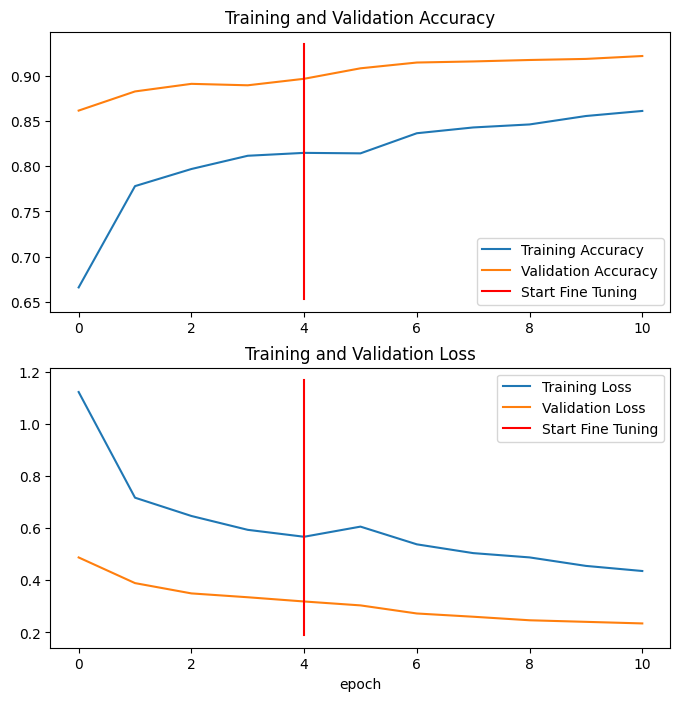

In [110]:
compare_history(history_4, history_5)